<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/35_polynomial_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

from mlxtend.plotting import plot_decision_regions

In [32]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/MachineLearning/main/ushape.csv")

In [33]:
df.head()

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0


In [34]:
X=df.iloc[:,0:2].values
y=df.iloc[:,-1].values

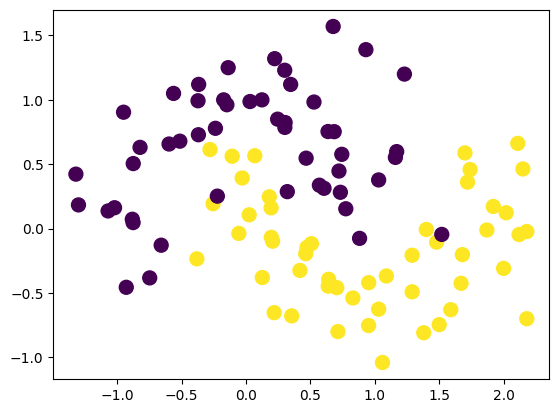

In [35]:
plt.scatter(X[:,0], X[:,1],c=y,s=100)

In [36]:
lr=LogisticRegression()
lr.fit(X,y)

LogisticRegression()

In [47]:
np.mean(cross_val_score(lr,X,y,cv=10,scoring="accuracy"))

np.float64(0.8300000000000001)

<Axes: >

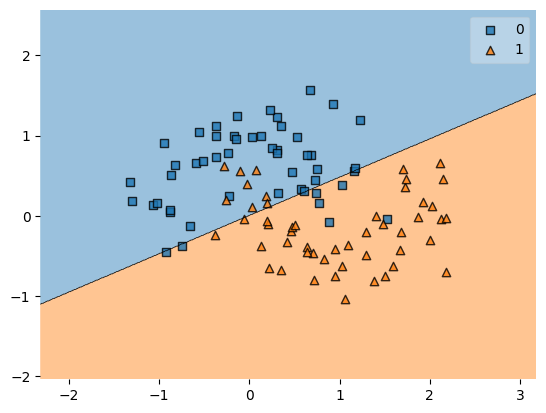

In [39]:
plot_decision_regions(X,y.astype(np.int_),lr)

In [52]:
ploy=PolynomialFeatures(degree=3)
x_trans=ploy.fit_transform(X)

In [53]:
clf1=LogisticRegression()
clf1.fit(x_trans,y)

LogisticRegression()

In [54]:
np.mean(cross_val_score(clf1,x_trans,y,cv=10,scoring="accuracy"))

np.float64(0.9)

In [62]:
def plot_decision_boundary(X,y,degree=1):

   poly = PolynomialFeatures(degree=degree)
   X_trf = poly.fit_transform(X)

   clf = LogisticRegression()
   clf.fit(X_trf,y)

   accuracy = np.mean(cross_val_score(clf,X_trf,y,scoring='accuracy',cv=10))

   a=np.arange(start=X[:,0].min()-1, stop=X[:,0].max()+1, step=0.01)
   b=np.arange(start=X[:,1].min()-1, stop=X[:,1].max()+1, step=0.01)


   XX,YY=np.meshgrid(a,b)

   input_array=np.array([XX.ravel(),YY.ravel()]).T

   labels=clf.predict(poly.transform(input_array))

   plt.contourf(XX,YY,labels.reshape(XX.shape),alpha=0.5)
   plt.scatter(X[:,0],X[:,1], c=y)
   plt.title('Degree = {}, accuracy is {}'.format(degree,np.round(accuracy,4)))

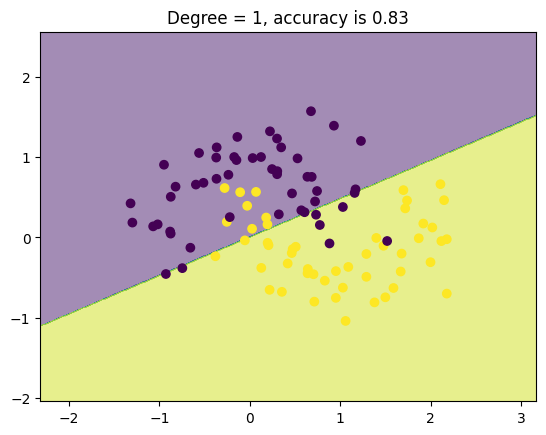

In [61]:
plot_decision_boundary(X,y)

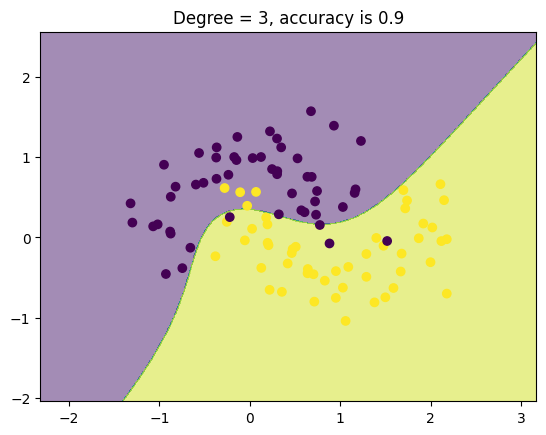

In [63]:
plot_decision_boundary(X,y,3)

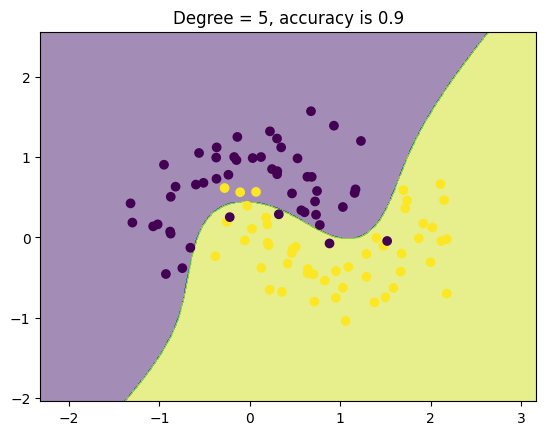

In [66]:
plot_decision_boundary(X,y,5)